In [1]:
import numpy as np
from numpy import random
import statistics as st
import matplotlib.pyplot as plt
import math
%matplotlib inline

In [17]:
def propensity(k,*args):
    
    for i in args:
        k=k*i
    return k


def ribosomebinding(a,b,c):
    
    if a>0 and b>0:
        a-=1
        b-=1
        c+=1
    return a,b,c


def releaserbs(a,b,c):
    
    if a>0:
        a-=1
        b+=1
        c+=1
    return a,b,c


def readthrough(a,b):
    
    if a>0:
        a-=1
        b+=1
    return a,b


# def slowcodon_index(codon_no, slowcodon_no):
    
#     position_list=list(range(codon_no))
#     random.seed()
#     primary_list=random.choice(position_list, slowcodon_no, replace=False)
#     index_list=sorted(primary_list)
    
#     return index_list


def get_reconstant1(codon_no, slowcodon_no):
    '''The first 20 codons are slow codons'''
    
    reconstant_list=[0.002]
    for i in range(codon_no):
        reconstant_list.append(12)
    
#     index_list=slowcodon_index(codon_no, slowcodon_no)
    
    for j in range(slowcodon_no):
        reconstant_list[j+1]=2
        
    return reconstant_list


def get_reconstant2(codon_no, slowcodon_no):
    '''The last 20 codons are slow codons'''
    
    reconstant_list=[0.002]
    for i in range(codon_no):
        reconstant_list.append(12)
    
#     index_list=slowcodon_index(codon_no, slowcodon_no)
    
    for j in range(codon_no-slowcodon_no,codon_no):
        reconstant_list[j+1]=2
        
    return reconstant_list


def get_reconstant3(codon_no, slowcodon_no):
    '''The 20 slow codons distribute evenly: 4 fast codons followed by 1 slow codon'''
    
    reconstant_list=[0.002]
    for i in range(codon_no):
        reconstant_list.append(12)
    
#     index_list=slowcodon_index(codon_no, slowcodon_no)
    
    for j in range(1,21):
        reconstant_list[5*j]=2
        
    return reconstant_list


def get_reconstant4(codon_no, slowcodon_no):
    '''The 20 slow codons distribute evenly: 3 fast codons followed by 1 slow codon then another fast codon'''
    
    reconstant_list=[0.002]
    for i in range(codon_no):
        reconstant_list.append(12)
    
#     index_list=slowcodon_index(codon_no, slowcodon_no)
    
    for j in range(1,21):
        reconstant_list[5*j-1]=2
        
    return reconstant_list


def get_reconstant5(codon_no, slowcodon_no):
    '''The 20 slow codons distribute evenly: 2 fast codons followed by 1 slow codon then another 2 fast codons'''
    
    reconstant_list=[0.002]
    for i in range(codon_no):
        reconstant_list.append(12)
    
#     index_list=slowcodon_index(codon_no, slowcodon_no)
    
    for j in range(1,21):
        reconstant_list[5*j-2]=2
        
    return reconstant_list


def get_reconstant6(codon_no, slowcodon_no):
    '''The 20 slow codons distribute evenly: 1 fast codons followed by 1 slow codon then another 3 fast codons'''
    
    reconstant_list=[0.002]
    for i in range(codon_no):
        reconstant_list.append(12)
    
#     index_list=slowcodon_index(codon_no, slowcodon_no)
    
    for j in range(1,21):
        reconstant_list[5*j-3]=2
        
    return reconstant_list


def get_reconstant7(codon_no, slowcodon_no):
    '''The 20 slow codons distribute evenly:1 slow codon followed by 4 fast codons'''
    
    reconstant_list=[0.002]
    for i in range(codon_no):
        reconstant_list.append(12)
    
#     index_list=slowcodon_index(codon_no, slowcodon_no)
    
    for j in range(1,21):
        reconstant_list[5*j-4]=2
        
    return reconstant_list



def directmethod(totalcodon_no, complex_list, reconstant_list, total_rib, rna, t1, occupied_pos):
    
    n=totalcodon_no
    
    rib=total_rib
    rna_rbs=rna
    
    prop_list=[] 
    prop1=propensity(reconstant_list[0],rib,rna_rbs)
#     print('R0', reconstant_list[0])
#     print('P1', prop1)
    
    prop_list.append(prop1)
    
#     print('PR', prop_list)
    
    for i in range(1,n):   # calculate the propensity of ribosome reading through the mRNA
#         print('i',i)
#         print(reconstant_list[i])
        prop_list.append(propensity(reconstant_list[i],complex_list[i-1]))
        
#     print('PROP', prop_list)
        
    if occupied_pos!=[]:  # occupied_pos stores the occupied codon positions, exclude them by resetting their propensities to 0
        new_prop = []   # will be used to store the propensities of reactions occurred in available codon positions
        for i, p in enumerate(prop_list):   # get the indexes and values of elements in prop_list
            if i not in occupied_pos:  # if the index of element is not in occupied_pos, it means that the position is available
                new_prop.append(p)  # just store the value into new_prop list
            else:   # else means the index of element is in occupied_pos, it means that the position has been occupied
                new_prop.append(0)  # just append 0 into the new_prop (means the reaction cannnot occur)
    else:
        new_prop = prop_list
        
#     print('NEW1', new_prop)
    
    sumprop=sum(new_prop)
    prob_list=[]
    
    if sumprop > 0:
        for i in new_prop: 
            prob_list.append(i/sumprop)  # calculate the probablity of each reaction
    
    if sum(prob_list)!=0:
        u=random.choice(np.arange(0,n),p=prob_list)  # choose u 
        tau=random.exponential(1/sumprop)    # choose time tau
        
        if u==0: # u==0, means ribosome binding into mRNA, update the number of ribosome, RNA_RBS and Ribosome-RNA_RBS complex
            rib,rna_rbs,complex_list[0]=ribosomebinding(rib,rna_rbs,complex_list[0]) 
            
        elif u==1: # u==1, means ribosome read through the second codon and release the RBS
            complex_list[0],complex_list[1],rna_rbs=releaserbs(complex_list[0],complex_list[1],rna_rbs) 
            
        elif u==n-1: # u==n-1, means the ribosome encounters the STOP or the last codon
            complex_list[u-1],rib=readthrough(complex_list[u-1],rib) 
            
        else:# else means the ribosome reads through other codon positions, regarded as the transition 
            # of Ribosome-RNA complex[i]-->Ribosome-RNA complex[i+1]
            complex_list[u-1],complex_list[u]=readthrough(complex_list[u-1],complex_list[u])
        
    newcomplex_list=[]  
    for i in range(len(complex_list)): # get and store the updated number of Ribosome-RNA complex[i] into newcomplex_list
        newcomplex_list.append(complex_list[i])
        
    rib1=rib  # get the updated number of free ribosome
    rna_rbs1=rna_rbs # get the updated number of RNA_RBS
    
    return newcomplex_list, rib1, rna_rbs1, tau, u


def simulation(codon_no,slowcodon_no, reconstant_list, total_rib,t1):
    
    t0=t1  # use t0 to store the initial value of t1 (stimulation starting time)
    t1_list=[]  # will be used to store the updating reaction time t1
    
    n=codon_no+1
    
#     reconstant_list=get_reconstant(codon_no, slowcodon_no)[0]
    
    complex_list=[0]*(n-1)  # set the initial value of complex_list (all the elements are 0)
    
    rib=total_rib # get the initial number of free ribosome
    
    rna_rbs=1  # the initial number of mRNA-RBS is 1 as only 1 mRNA is involved in the simulation
    
    result={}  # will be used to store the time and positions of each individual reaction
    
    ids=0  # will be used as the ID of new reaction (also as the name of reaction)
    u_list=[]   # will be used to store the generated u at each step
    
    occupied_pos=[]  # will be used to store the codon postions that has been occupied (reaction cannot occur)

    number=0   # the number of proteins that have been translated completely
    
    while number<100:  

        y=directmethod(n, complex_list, reconstant_list, rib, rna_rbs, t1, occupied_pos)  # run direct method
        u=y[-1]  # get u
        
#         print('U', u)
        
        if u_list==[]:    # at first u_list is empty, 
            complex_list=y[0]  # update the molecular number of Rib-RNA complex[i], free ribosome and RNA_RBS
            rib=y[1]
            rna_rbs=y[2]
            
            t1+=y[3]  # update the reaction time t1
            t1_list.append(t1)  # store the updated time 
            
            u_list.append(u)  # store the u generated from this step (then u_list is not empty)
            
            ids+=1  # start a new reaction (ids will be used as the name of new reaction)
            result[ids]=[(t1,u)]  # store the tuple of (reaction time, u) into dictionary (the ids will be the key)
            
            occupied_pos=[u]  # update the occupied_pos
            
        else:  # then u_list is not empty 
            complex_list=y[0]   # update number of Ribosome-RNA[i], free ribosome and RNA-RBS
            rib=y[1]
            rna_rbs=y[2]

            u_list.append(u)
            
            if u==0:   # if u==0, means a new peptide translation reaction has occurred
                ids+=1   # use the new ids as the name of this new reaction
                t1 += y[3]  # update the reaction time
                t1_list.append(t1)  # store the updated reaction time t1 into t1_list
                result[ids]=[(t1,u)]  # store the tuple of (reaction time, u) into dictionary (the new ids will be the key)
        
            else:  # if u!=0, means one of the current peptide reaction is continuing
                t1 += y[3]  # updating the reaction time
                t1_list.append(t1)  # store the updated reaction time t1 into t1_list
                for k, v in result.items(): # then check which reaction is continuing,
                    if v[-1][-1]==u-1: # v[-1][-1] is the last codon position of each individual reaction, if v[-1][-1]==u-1,
                        result[k].append((t1, u)) # it means this peptide translation reaction is occuring, just append the 
                                                 # tuple of (reaction time, u) into result dictionary under this key, and also
                        break                   # append the translated amino acid into aa_result dictionary under this key
                        
            occupied_pos = [v[-1][-1] for v in result.values() if v[-1][-1]!=n-1]
            occupied_pos = [v - 9 for v in occupied_pos if v>8]+[v - 8 for v in occupied_pos if v>7]+\
            [v - 7 for v in occupied_pos if v>6]+[v - 6 for v in occupied_pos if v>5]+[v - 5 for v in occupied_pos if v>4]+\
            [v - 4 for v in occupied_pos if v>3]+[v - 3 for v in occupied_pos if v>2]+[v - 2 for v in occupied_pos if v>1]+\
            [v - 1 for v in occupied_pos if v>0] + occupied_pos  
            
#             print('OCC', occupied_pos)
            
            if u==n-1:  # if u==n-1, it means the one protein has been translated completely
                number+=1  # update the number of proteins that have been translated completely.
            else:
                pass
   
    return result, u_list, t1



def calculate_oneprotein(codon_no,slowcodon_no, reconstant_list, total_rib,t1):
    
    y=simulation(codon_no,slowcodon_no, reconstant_list, total_rib,t1)
    
    protein_dic={}

    for k, v in y[0].items():
        if v[-1][-1]==codon_no:
            protein_dic[k]=v[-1][0]-v[0][0]
         
    keylist=list(protein_dic.keys())
    keylist.sort()
    
    time_list=[]
    
    for k in keylist:
        time_list.append(protein_dic[k])
    
    print('TIME', time_list, len(time_list))
    
    stable_list=time_list[20:]
    print('STABLE', stable_list, len(stable_list))
    
    sum_stable=sum(stable_list)
    print('SUM', sum_stable)
    
                
    return protein_dic, time_list, stable_list, sum_stable
                
    
    
def repeat_calculation(codon_no,slowcodon_no, reconstant_list, total_rib,t1, repeat_time):
    
    total_time_list=[]
    total_sum=[]
    
    meantime_list=[]
    std_list=[]
    se_list=[]
    
    for i in range(repeat_time):
        y=calculate_oneprotein(codon_no,slowcodon_no, reconstant_list, total_rib,t1)
        total_time_list.append(y[2])
        total_sum.append(y[-1])
    
    print('TOTAL', total_time_list, len(total_time_list))
    print('TOTAL SUM', total_sum, len(total_sum))
    
    s_list=[]
    for j in range(80):
#         s_list=[]
        for i in total_time_list:
            print(i[j])
            s_list.append(i[j])
     
    print('S_LIST', s_list, len(s_list))
            
    meantime_list.append(sum(s_list)/(80*repeat_time))
    std_list.append(st.stdev(s_list))
    se_list.append(st.stdev(s_list)/math.sqrt(80*repeat_time))
            
#     print('MEAN', meantime_list,len(meantime_list))
#     print('STD',std_list,len(std_list))
#     print('SE',se_list,len(se_list))

    return meantime_list,std_list,se_list
        

In [18]:
# simulation(codon_no,slowcodon_no, total_rib,t1)

codon_no=100
slowcodon_no=20
rib=50
t1=0
repeat_time=3

reconstant_list=get_reconstant1(codon_no,slowcodon_no)
print('Reconstant', reconstant_list)


# y=calculate_oneprotein(codon_no,slowcodon_no, reconstant_list, rib,t1)

z=repeat_calculation(codon_no,slowcodon_no, reconstant_list, rib,t1, repeat_time)
print('MEAN', z[0])
print('SE',z[2])

# x=repeat_sequence(codon_no, slowcodon_no, rib, t1, repeat_time, eachconstant_time)
# print(x)

# m=np.array(range(100))
# n=np.array(z[0])
# e=np.array(z[-1])

# plt.errorbar(m, n, e, linestyle='None', marker='^')

# # plt.plot(m,n)

# # plt.plot(m,n)

# plt.title('Time needed to translate each proteins with 50 ribosomes - Arrangement 1')
# plt.xlabel('Index of Protein')
# plt.ylabel('Time/s')

# plt.show()

# varied_ribosome(codon_no, slowcodon_no, rib, t1, repeat_time, eachconstant_time)

Reconstant [0.002, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12]
TIME [17.1182532446473, 14.535990656996827, 14.872011104587948, 18.331630323611186, 14.794893876768903, 17.19231651877581, 19.278413737625186, 18.14811082884212, 17.677124987713512, 18.390361479607805, 18.050940582914023, 13.283809633796807, 18.996516445504454, 16.11466530130471, 12.058918040342661, 14.835141052277578, 14.448578026915726, 12.918860361039947, 15.84635749695832, 13.929003627177963, 18.083929588297565, 12.668711946409417, 16.868841859657607, 15.908599257248511, 18.543205922702725, 15.835551140235964, 17.26607785526994, 13.736096955720939, 17.17460026010673, 17.16041662767566, 17.5

Reconstant [0.002, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
Z [16.715080626945856, 18.340899043969227, 18.940884124062343, 19.465335441776602, 19.663505899393684, 20.068832801291006, 20.27235891092886, 20.45080808410293, 20.509708097914828, 20.6683818353865, 20.62784301063544, 20.542177177245538, 20.67632373093334, 20.63105428252342, 20.61190221946994, 20.719715163680267, 20.675393346636636, 20.497836453309247, 20.848750755731494, 20.707071998810324, 20.53672138538016, 20.841472281980327, 21.070413545234576, 20.839505075485725, 20.620067460347883, 20.656688249904928, 20.654052929192755, 20.53830229401956, 20.619849002196936, 20.62293884301066, 20.627070

C:\Users\zhpc\Anaconda3\lib\site-packages\matplotlib\collections.py:590: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if self._edgecolors == str('face'):


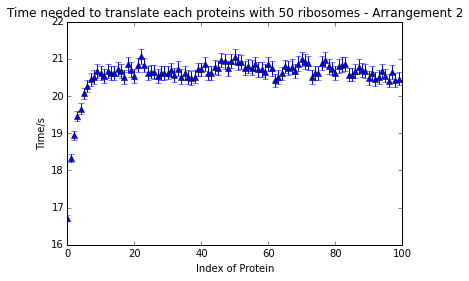

In [13]:
# simulation(codon_no,slowcodon_no, total_rib,t1)

codon_no=100
slowcodon_no=20
rib=50
t1=0
repeat_time=1000

reconstant_list=get_reconstant2(codon_no,slowcodon_no)
print('Reconstant', reconstant_list)


# y=calculate_oneprotein(codon_no,slowcodon_no, reconstant_list, rib,t1)

z=repeat_calculation(codon_no,slowcodon_no, reconstant_list, rib,t1, repeat_time)
print('Z', z[0])

# x=repeat_sequence(codon_no, slowcodon_no, rib, t1, repeat_time, eachconstant_time)
# print(x)

m=np.array(range(100))
n=np.array(z[0])
e=np.array(z[-1])

plt.errorbar(m, n, e, linestyle='None', marker='^')

# plt.plot(m,n)

# plt.plot(m,n)

plt.title('Time needed to translate each proteins with 50 ribosomes - Arrangement 2')
plt.xlabel('Index of Protein')
plt.ylabel('Time/s')

plt.show()


Reconstant [0.002, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2]
Z [16.587553871295725, 17.03082470505504, 17.110894763340717, 17.214983790525803, 17.130558125915343, 17.167767821572642, 17.201486979573126, 17.18082539611622, 17.097258980343305, 17.158656282742825, 17.031414128066388, 17.128689258575314, 17.08330486660223, 17.124102490133367, 17.087352309355456, 17.163648581355215, 17.240636849751976, 17.224253306187727, 17.082349861397493, 17.262883105647827, 17.237966146165085, 17.230244743429772, 17.276565429034395, 17.314770454610127, 17.143562359379473, 17.187101029215604, 17.219155273521306, 17.11032679047916, 17.33717470912166, 17.26487610709083, 17.1

C:\Users\zhpc\Anaconda3\lib\site-packages\matplotlib\collections.py:590: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if self._edgecolors == str('face'):


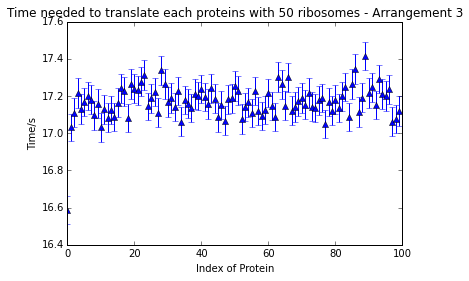

In [ ]:
# simulation(codon_no,slowcodon_no, total_rib,t1)

codon_no=100
slowcodon_no=20
rib=50
t1=0
repeat_time=1000

reconstant_list=get_reconstant3(codon_no,slowcodon_no)
print('Reconstant', reconstant_list)


# y=calculate_oneprotein(codon_no,slowcodon_no, reconstant_list, rib,t1)

z=repeat_calculation(codon_no,slowcodon_no, reconstant_list, rib,t1, repeat_time)
print('Z', z[0])

# x=repeat_sequence(codon_no, slowcodon_no, rib, t1, repeat_time, eachconstant_time)
# print(x)

m=np.array(range(100))
n=np.array(z[0])
e=np.array(z[-1])

plt.errorbar(m, n, e, linestyle='None', marker='^')

# plt.plot(m,n)

# plt.plot(m,n)

plt.title('Time needed to translate each proteins with 50 ribosomes - Arrangement 3')
plt.xlabel('Index of Protein')
plt.ylabel('Time/s')

plt.show()


Reconstant [0.002, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12]
Z [16.61238877748061, 16.9681141371241, 17.18391076249285, 17.13775751817377, 17.2432600179041, 17.152582993056665, 17.171602843885633, 17.11583396202476, 17.121258722243194, 17.225296618527594, 17.245871516557564, 17.166881118148396, 17.18794461402474, 17.08701956855081, 17.202844096976694, 17.174111947565397, 17.177315583361793, 17.319487756568584, 17.270030919917104, 17.10059135905974, 17.141572946012, 17.294011338351126, 17.24854230780023, 17.18367306396583, 17.139706344303885, 17.151117385737923, 17.221005532333738, 17.192808263987292, 17.33575413958308, 17.117395073790288, 17.220646248008

C:\Users\zhpc\Anaconda3\lib\site-packages\matplotlib\collections.py:590: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if self._edgecolors == str('face'):


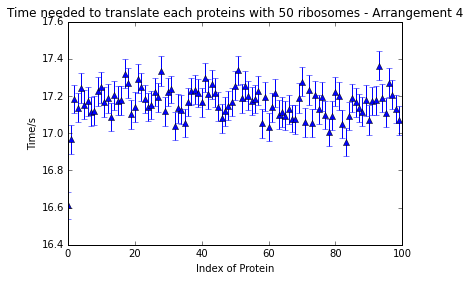

In [18]:
# simulation(codon_no,slowcodon_no, total_rib,t1)

codon_no=100
slowcodon_no=20
rib=50
t1=0
repeat_time=1000

reconstant_list=get_reconstant4(codon_no,slowcodon_no)
print('Reconstant', reconstant_list)


# y=calculate_oneprotein(codon_no,slowcodon_no, reconstant_list, rib,t1)

z=repeat_calculation(codon_no,slowcodon_no, reconstant_list, rib,t1, repeat_time)
print('Z', z[0])

# x=repeat_sequence(codon_no, slowcodon_no, rib, t1, repeat_time, eachconstant_time)
# print(x)

m=np.array(range(100))
n=np.array(z[0])
e=np.array(z[-1])

plt.errorbar(m, n, e, linestyle='None', marker='^')

# plt.plot(m,n)

# plt.plot(m,n)

plt.title('Time needed to translate each proteins with 50 ribosomes - Arrangement 4')
plt.xlabel('Index of Protein')
plt.ylabel('Time/s')

plt.show()


Reconstant [0.002, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12]
Z [16.672782412572197, 16.9575469680367, 17.01867695909377, 16.971229461053923, 16.996181841506985, 17.238326545367286, 17.188952091893327, 17.151826324496454, 17.156036296940812, 17.277551853764333, 17.150242392651528, 17.064024329313057, 17.122994978424817, 17.157696826878468, 17.091010534711522, 17.182201389958237, 17.204940747464686, 17.188051206395528, 17.189538248423776, 17.185588940122624, 17.165309061086372, 17.160791562039698, 17.116894576113364, 17.018113588030356, 17.162368192047396, 17.242488006995735, 17.16770781225725, 17.11318321791329, 17.1239305482905, 17.129097996586736, 17.14

C:\Users\zhpc\Anaconda3\lib\site-packages\matplotlib\collections.py:590: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if self._edgecolors == str('face'):


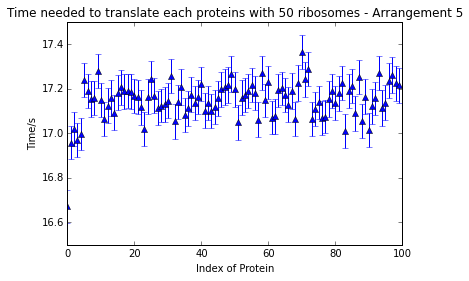

In [19]:
# simulation(codon_no,slowcodon_no, total_rib,t1)

codon_no=100
slowcodon_no=20
rib=50
t1=0
repeat_time=1000

reconstant_list=get_reconstant5(codon_no,slowcodon_no)
print('Reconstant', reconstant_list)


# y=calculate_oneprotein(codon_no,slowcodon_no, reconstant_list, rib,t1)

z=repeat_calculation(codon_no,slowcodon_no, reconstant_list, rib,t1, repeat_time)
print('Z', z[0])

# x=repeat_sequence(codon_no, slowcodon_no, rib, t1, repeat_time, eachconstant_time)
# print(x)

m=np.array(range(100))
n=np.array(z[0])
e=np.array(z[-1])

plt.errorbar(m, n, e, linestyle='None', marker='^')

# plt.plot(m,n)

# plt.plot(m,n)

plt.title('Time needed to translate each proteins with 50 ribosomes - Arrangement 5')
plt.xlabel('Index of Protein')
plt.ylabel('Time/s')

plt.show()


Reconstant [0.002, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12]
Z [16.647234389796143, 16.977209959762657, 17.063796553608093, 17.139280348286746, 17.28700212041797, 17.29541312301365, 17.215451371205585, 17.14482520999821, 17.05262107892823, 17.132010495489375, 17.108614457409715, 17.09820341966287, 17.112526345186584, 17.092934171046274, 17.065380146435434, 17.043744444401078, 17.246031053835377, 17.26818309416484, 17.05569969984942, 17.160229061573766, 17.17909794065688, 17.227444633372627, 17.129039864788854, 17.189117493794587, 17.200317094269696, 17.168669042262362, 17.09722524125973, 17.187797021175065, 17.09920172946969, 17.181530841566495, 17.16325

C:\Users\zhpc\Anaconda3\lib\site-packages\matplotlib\collections.py:590: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if self._edgecolors == str('face'):


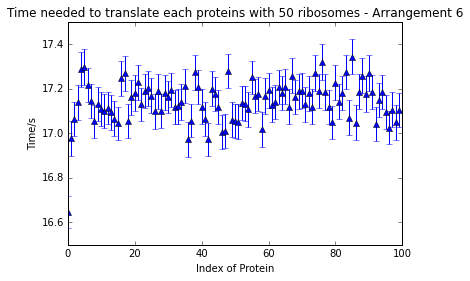

In [20]:
# simulation(codon_no,slowcodon_no, total_rib,t1)

codon_no=100
slowcodon_no=20
rib=50
t1=0
repeat_time=1000

reconstant_list=get_reconstant6(codon_no,slowcodon_no)
print('Reconstant', reconstant_list)


# y=calculate_oneprotein(codon_no,slowcodon_no, reconstant_list, rib,t1)

z=repeat_calculation(codon_no,slowcodon_no, reconstant_list, rib,t1, repeat_time)
print('Z', z[0])

# x=repeat_sequence(codon_no, slowcodon_no, rib, t1, repeat_time, eachconstant_time)
# print(x)

m=np.array(range(100))
n=np.array(z[0])
e=np.array(z[-1])

plt.errorbar(m, n, e, linestyle='None', marker='^')

# plt.plot(m,n)

# plt.plot(m,n)

plt.title('Time needed to translate each proteins with 50 ribosomes - Arrangement 6')
plt.xlabel('Index of Protein')
plt.ylabel('Time/s')

plt.show()


Reconstant [0.002, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12, 2, 12, 12, 12, 12]
Z [16.706336744199845, 17.101163181674988, 17.171480687699642, 17.1928592566718, 17.129632806989793, 17.22417114631592, 17.234136097168378, 17.088457407341902, 17.073708439697487, 17.222098935933612, 17.140013952113367, 17.129075509191228, 17.248986054210153, 17.23068847252007, 17.250272692295045, 17.094750574963452, 16.99772288554054, 17.065123809473796, 17.272422940282834, 17.234521680054243, 17.2966669501454, 17.175877455521405, 17.117140159655854, 17.215927720684622, 17.18338129773602, 17.068215744472543, 17.0872066159875, 17.165495971186186, 17.043226291552, 17.180312433273812, 17.08794236

C:\Users\zhpc\Anaconda3\lib\site-packages\matplotlib\collections.py:590: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if self._edgecolors == str('face'):


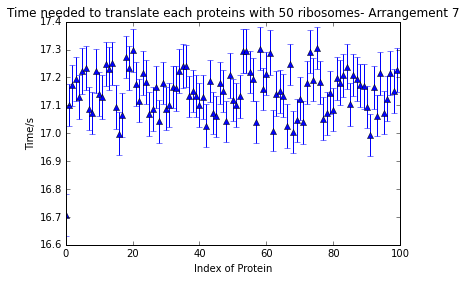

In [21]:
# simulation(codon_no,slowcodon_no, total_rib,t1)

codon_no=100
slowcodon_no=20
rib=50
t1=0
repeat_time=1000

reconstant_list=get_reconstant7(codon_no,slowcodon_no)
print('Reconstant', reconstant_list)


# y=calculate_oneprotein(codon_no,slowcodon_no, reconstant_list, rib,t1)

z=repeat_calculation(codon_no,slowcodon_no, reconstant_list, rib,t1, repeat_time)
print('Z', z[0])

# x=repeat_sequence(codon_no, slowcodon_no, rib, t1, repeat_time, eachconstant_time)
# print(x)

m=np.array(range(100))
n=np.array(z[0])
e=np.array(z[-1])

plt.errorbar(m, n, e, linestyle='None', marker='^')

# plt.plot(m,n)

# plt.plot(m,n)

plt.title('Time needed to translate each proteins with 50 ribosomes- Arrangement 7')
plt.xlabel('Index of Protein')
plt.ylabel('Time/s')

plt.show()
